# Example usage of ABCI-Categorical-GP

This notebook illustrates the example usage of ABCI with a categorical
distribution over graphs and a GP mechanism model. This setup scales up to systems with
four variables.

In [ ]:
# !conda uninstall pytorch
# !conda install pytorch==1.9.1 torchaudio=0.9.1 torchvision=0.10.1 cpuonly -c pytorch
# %conda install requests
#keras, tensorflow, chardet, charset-normalizer==2.1.0

In [15]:
# imports
%reload_ext autoreload
%autoreload 2


import matplotlib.pyplot as plt
import torch.distributions as dist
from matplotlib.ticker import MaxNLocator

from src.abci_categorical_gp import ABCICategoricalGP as ABCI
from src.environments.generic_environments import *
from src.models.gp_model import get_graph_key, gather_data


In [6]:
import torch
import torchvision
import torchvision.transforms as transforms

# Step 1: Define the transformation to normalize and flatten the data
transform = transforms.Compose([
    transforms.ToTensor(),  # Convert PIL image to Tensor
    transforms.Normalize((0.5,), (0.5,)),  # Normalize to [-1, 1]
    transforms.Lambda(lambda x: x.view(-1))  # Flatten the 28x28 image to a 784 vector
])

# Step 2: Load the MNIST dataset with the transformation
train_dataset = torchvision.datasets.MNIST(root='./data', train=True, download=True, transform=transform)
train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=32, shuffle=True)

# Step 3: Access a batch of data
data_iter = iter(train_loader)
X1_data, X2_data = data_iter.next()

# Print the shapes
print(f'X1_data shape (flattened images): {X1_data.shape}')  # Expected shape: (batch_size, 784)
print(f'X2_data shape (labels): {X2_data.shape}')  # Expected shape: (batch_size,)


X1_data shape (flattened images): torch.Size([32, 784])
X2_data shape (labels): torch.Size([32])


In [7]:
import torch
import networkx as nx
from src.environments.experiment import Experiment

# Example custom data with an inverse pattern between X1 and X2
num_batches = 1
batch_size = 32

# Combine into custom data for experiments
custom_data = {'X1': X1_data, 'X2': X2_data}

# Example interventions dictionary (no interventions in this case)
custom_interventions = {'X1': True, 'X2': False}

# Create an Experiment instance with custom data
experiment = Experiment(interventions=custom_interventions, data=custom_data)

# Create a list of Experiment instances
experiments = [experiment]

shapes = {'X1': 784, 'X2': 784}

# Define a simple graph structure where X1 influences X2
graph_test = nx.DiGraph()
graph_test.add_edges_from([('X1', 'X2')])  # X1 influences X2

# # Call the gather_data function with custom experiments and graph
# inputs, targets = gather_data(experiments, 'X1', graph=graph, mode='joint')

# # Print the extracted inputs and targets to see if the inverse relationship is captured
# print("Inputs:", inputs)
# print("Targets:", targets)


In [ ]:
# specify the number of nodes and (optionally) a query of interventional variables
num_nodes = 2
# interventional_queries = None
interventional_queries = [InterventionalDistributionsQuery(['X2'], {'X1': dist.Uniform(3, 4.)}, sample_queries=experiments)]

# generate the ground truth environment
env = BiDiag(num_nodes,
             num_test_queries=10,
             interventional_queries=interventional_queries,
graph=graph_test,
base_shapes = shapes)

# plot true graph
nx.draw(env.graph, nx.planar_layout(env.graph), labels=dict(zip(env.graph.nodes, env.graph.nodes)))


In [7]:
print(X1_data.shape)
print(X2_data.shape)

env.mechanisms['X2'].set_data(X1_data, X2_data) #.squeeze(-1))

torch.Size([32, 784])
torch.Size([32])


In [6]:
import gpytorch

gp_model = env.mechanisms['X2'].gp  # The Gaussian Process for 'X1'
gp_model.train()

likelihood = gpytorch.likelihoods.GaussianLikelihood()
mll = gpytorch.mlls.ExactMarginalLogLikelihood(likelihood, gp_model)
optimizer = torch.optim.Adam(gp_model.parameters(), lr=0.01)
num_epochs = 1000
for epoch in range(num_epochs):
    optimizer.zero_grad()
    output = gp_model(X1_data)
    # print(output.shape)
    loss = -mll(output, X2_data.squeeze(-1)).mean()
    # print(loss.shape)
    loss.backward()
    optimizer.step()
    if epoch % 500 == 0:
        print(f'Epoch {epoch + 1}/{num_epochs}, Loss: {loss.item()}')
print('Training Process Completed')
# tester = noise = torch.randn(10)
# tester.dim()



Epoch 1/1000, Loss: 3.1698427200317383
Epoch 501/1000, Loss: 2.4917948246002197
Training Process Completed


Next, we can examine the ground truth mechanisms.

output shape is currently f_dist.mean torch.Size([1])
tensor([6.9705])


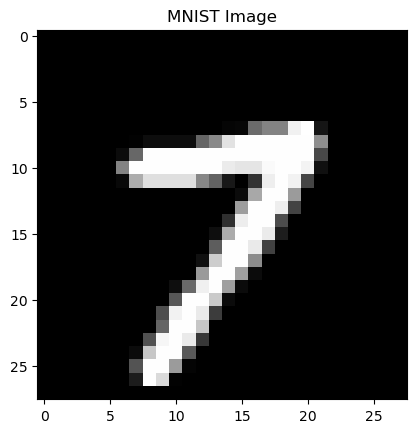

In [11]:
import matplotlib.pyplot as plt

ytrue = env.mechanisms['X2'](X1_data[0].view(1,784), prior_mode=False).detach()
print(ytrue[0])

mnist_image_2d = X1_data[0].view(28, 28)

# Plot the image using matplotlib
plt.imshow(mnist_image_2d, cmap='gray')
plt.title('MNIST Image')
plt.show()

Here, we create an ABCI instance with the desired experimental design policy.

In [8]:
policy = 'observational'
abci = ABCI(env, policy)

We can now run a number of ABCI loops.

In [9]:
num_experiments = 3
batch_size = 3

abci.run(num_experiments, batch_size, num_initial_obs_samples=3)

pass 1
num batches 50
batch size 1
trying to execute mll
excepion not occuring
trying to execute mll
Ill-shaped inputs: torch.Size([50, 1, 1]). Expected ends with 784
Exception occured in Environment.log_likelihood() when computing LL for mechanism X2:
None
pass 2
trying to execute mll
Ill-shaped inputs: torch.Size([39200, 1, 1]). Expected ends with 784
Exception occured in Environment.log_likelihood() when computing LL for mechanism X2:
None
trying to execute mll
excepion not occuring
Starting experiment cycle 1/3...
Design and perform experiment...
set node X1, with data of shape torch.Size([1, 3, 1])
node X2 expected shape (1, 3, 784), giving torch.Size([1, 3, 1])
Invalid shape torch.Size([1, 3, 1])!


AssertionError: None

Here, we plot the training stats and results.

In [ ]:
print(f'Number of observational batches: {len([e for e in abci.experiments if e.interventions == {}])}')
for node in env.node_labels:
    print(
        f'Number of interventional batches on {node}: {len([e for e in abci.experiments if node in e.interventions])}')

# plot expected SHD over experiments
ax = plt.figure().gca()
plt.plot(abci.eshd_list)
plt.xlabel('Number of Experiments')
plt.ylabel('Expected SHD')
ax.xaxis.set_major_locator(MaxNLocator(integer=True))

# plot true graph NLL over experiments
ax = plt.figure().gca()
plt.plot(-torch.tensor(abci.graph_ll_list))
plt.xlabel('Number of Experiments')
plt.ylabel('True Graph NLL')
ax.xaxis.set_major_locator(MaxNLocator(integer=True))

# plot graph posterior
graphs = abci.graph_posterior.sort_by_prob()[0:10]
probs = [abci.graph_posterior.log_prob(g).exp().detach() for g in graphs]
graph_keys = [get_graph_key(g) for g in graphs]

plt.figure()
plt.xticks(rotation=90)
plt.bar(graph_keys, probs)
plt.ylabel(r'Graph Posterior, $p(G|D)$')

# plot graph posterior entropy over experiments
ax = plt.figure().gca()
plt.plot(abci.graph_entropy_list, label='entropy estimate')
plt.xlabel('Number of Experiments')
plt.ylabel('Entropy of Graph Posterior')
ax.xaxis.set_major_locator(MaxNLocator(integer=True))
plt.legend()

# plot Query KLD over experiments
ax = plt.figure().gca()
plt.plot(abci.query_kld_list)
plt.xlabel('Number of Experiments')
plt.ylabel('Query KLD')
ax.xaxis.set_major_locator(MaxNLocator(integer=True))
plt.tight_layout()

Finally, we can have a look at the learned vs. true mechanisms.

In [ ]:
# plot X_i -> X_j true vs. predicted
i = 1
j = 2
xdata, ydata = gather_data(abci.experiments, f'X{j}', parents=[f'X{i}'])
xrange = torch.linspace(xdata.min(), xdata.max(), 100).unsqueeze(1)
ytrue = env.mechanisms[f'X{j}'](xrange).detach()
mech = abci.mechanism_model.get_mechanism(f'X{j}', parents=[f'X{i}'])
mech.set_data(xdata, ydata)
ypred = mech(xrange).detach()

plt.figure()
plt.plot(xdata, ydata, 'rx', label='Experimental Data')
plt.plot(xrange, ytrue, label=f'X{i}->X{j} true')
plt.plot(xrange, ypred, label=f'X{i}->X{j} prediction')
plt.xlabel(f'X{i}')
plt.ylabel(f'X{j}')
plt.legend()
plt.tight_layout()

In [ ]:
# plot bivariate mechanisms
node = 'X2'
num_points = 100
xrange = torch.linspace(-10., 10., num_points)
yrange = torch.linspace(-10., 10., num_points)
xgrid, ygrid = torch.meshgrid(xrange, yrange)
inputs = torch.stack((xgrid, ygrid), dim=2).view(-1, 2)
ztrue = env.mechanisms[node](inputs).detach().view(num_points, num_points).numpy()

parents = ['X1']
mech = abci.mechanism_model.get_mechanism(node, parents=parents)
zpred = mech(inputs)
zpred = zpred.detach().view(num_points, num_points).numpy()

zmin = ztrue.min().item()
zmax = ztrue.max().item()
print(f'Function values for {node} in range [{zmin, zmax}].')

levels = torch.linspace(zmin, zmax, 30).numpy()
fig, axes = plt.subplots(1, 2)
cp1 = axes[0].contourf(xgrid, ygrid, ztrue, cmap=plt.get_cmap('jet'), levels=levels, vmin=zmin, vmax=zmax)
cp2 = axes[1].contourf(xgrid, ygrid, zpred, cmap=plt.get_cmap('jet'), levels=levels, vmin=zmin, vmax=zmax)

inputs, targets = gather_data(abci.experiments, node, parents=parents)
axes[0].plot(inputs[:, 0], inputs[:, 1], 'kx')

axes[0].set_xlabel(parents[0])
axes[1].set_xlabel(parents[0])
axes[0].set_ylabel(parents[1])
_ = fig.colorbar(cp2)